📸 Images sélectionnées :
   1011404.jpg
   1016217.jpg
   1009426.jpg
🎯 Pizza      → ['pizza 91%', 'wine glass 25%', 'dining table 20%']
🎯 Steak      → ['pizza 67%']
🎯 Hamburger  → ['sandwich 48%', 'donut 33%', 'donut 28%']


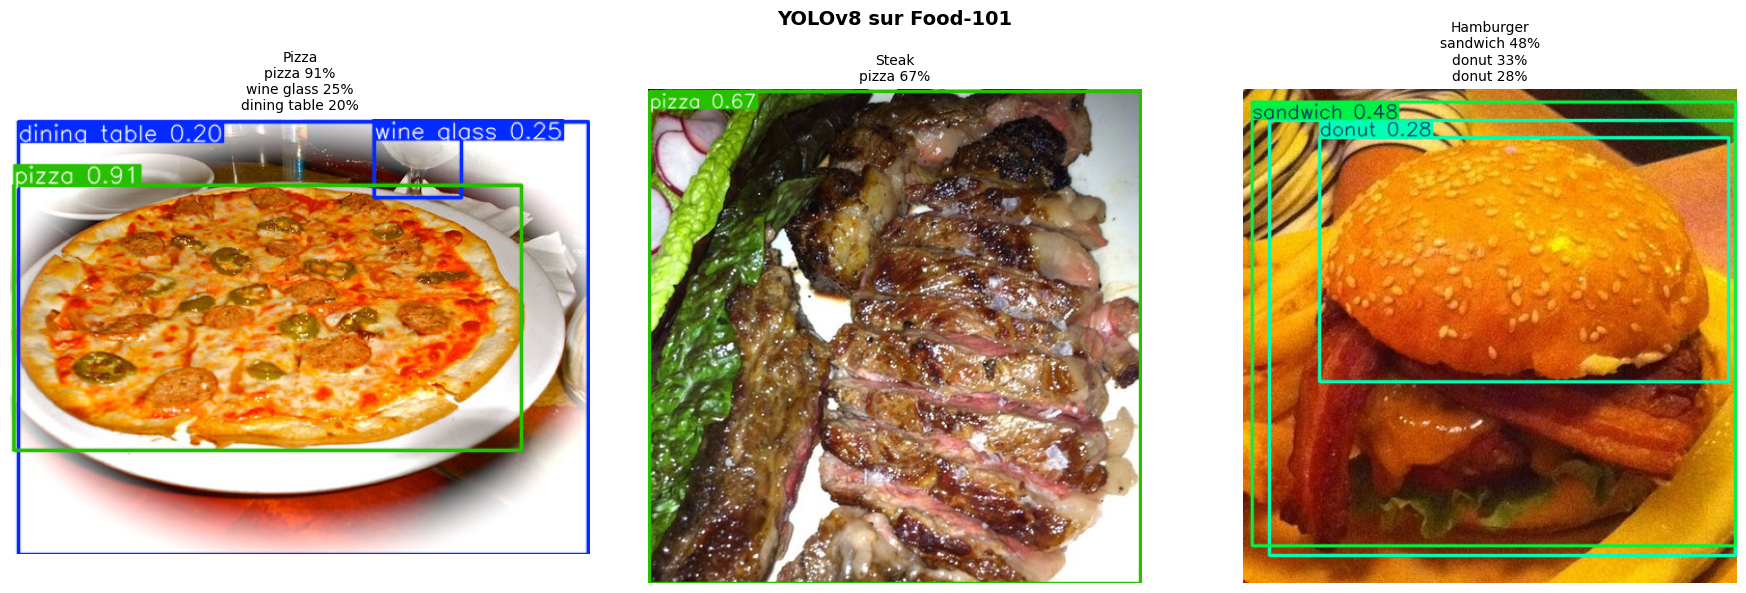

✅ Test YOLO sauvegardé


In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path

# ── Utiliser des images déjà présentes ───────────────────
images_dir = Path("C:/SmartMeal/data/food101/food-101/food-101/images")

# Prendre une image de pizza et une de steak
img_pizza  = list((images_dir / "pizza").glob("*.jpg"))[5]
img_steak  = list((images_dir / "steak").glob("*.jpg"))[5]
img_burger = list((images_dir / "hamburger").glob("*.jpg"))[5]

print(f"📸 Images sélectionnées :")
print(f"   {img_pizza.name}")
print(f"   {img_steak.name}")
print(f"   {img_burger.name}")

# ── YOLO sur plusieurs images ─────────────────────────────
model_yolo = YOLO("yolov8n.pt")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, img_path, title in zip(
    axes,
    [img_pizza, img_steak, img_burger],
    ["Pizza", "Steak", "Hamburger"]
):
    results = model_yolo(str(img_path), conf=0.15, verbose=False)
    
    detections = []
    for box in results[0].boxes:
        name = model_yolo.names[int(box.cls)]
        conf = float(box.conf) * 100
        detections.append(f"{name} {conf:.0f}%")
    
    img_annotated = results[0].plot()
    ax.imshow(img_annotated[:, :, ::-1])
    ax.axis("off")
    
    detected_str = "\n".join(detections) if detections else "Aucun objet COCO"
    ax.set_title(f"{title}\n{detected_str}", fontsize=10)
    print(f"🎯 {title:10s} → {detections if detections else 'rien détecté'}")

plt.suptitle("YOLOv8 sur Food-101", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("C:/SmartMeal/reports/yolo_test.png", dpi=150)
plt.show()
print("✅ Test YOLO sauvegardé")
